<a href="https://colab.research.google.com/gist/bharath-mummadi/43152f619a28071536b0911ef9dc4c4d/untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Dataset
movies = {
    "Movie_ID": ["M1","M2","M3","M4","M5"],
    "Title": ["Space Jam","Dark Space","Love Story","Sweet Heart","Alien Hunt"],
    "Genre": ["Sci-Fi","Sci-Fi","Romance","Romance","Sci-Fi"],
    "Keywords": [
        "galaxy space alien",
        "space planet alien",
        "couple love heart",
        "love family smile",
        "alien hunter space"
    ]
}

df = pd.DataFrame(movies)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(lowercase=True)
tfidf_matrix = tfidf.fit_transform(df["Keywords"])

print("TF-IDF Matrix:")
print(pd.DataFrame(tfidf_matrix.toarray(),
                   columns=tfidf.get_feature_names_out(),
                   index=df["Movie_ID"]))

TF-IDF Matrix:
            alien    couple    family    galaxy     heart    hunter      love  \
Movie_ID                                                                        
M1        0.48624  0.000000  0.000000  0.726044  0.000000  0.000000  0.000000   
M2        0.48624  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
M3        0.00000  0.614189  0.000000  0.000000  0.614189  0.000000  0.495524   
M4        0.00000  0.000000  0.614189  0.000000  0.000000  0.000000  0.495524   
M5        0.48624  0.000000  0.000000  0.000000  0.000000  0.726044  0.000000   

            planet     smile    space  
Movie_ID                               
M1        0.000000  0.000000  0.48624  
M2        0.726044  0.000000  0.48624  
M3        0.000000  0.000000  0.00000  
M4        0.000000  0.614189  0.00000  
M5        0.000000  0.000000  0.48624  


In [2]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    cosine_sim,
    index=df["Movie_ID"],
    columns=df["Movie_ID"]
)

print(similarity_df)

Movie_ID        M1        M2        M3        M4        M5
Movie_ID                                                  
M1        1.000000  0.472859  0.000000  0.000000  0.472859
M2        0.472859  1.000000  0.000000  0.000000  0.472859
M3        0.000000  0.000000  1.000000  0.245544  0.000000
M4        0.000000  0.000000  0.245544  1.000000  0.000000
M5        0.472859  0.472859  0.000000  0.000000  1.000000


In [3]:
scores = list(enumerate(cosine_sim[0]))

scores = sorted(scores, key=lambda x: x[1], reverse=True)

print("Top 2 Similar Movies to Space Jam:")

count = 0
for i, score in scores[1:]:
    print(df.iloc[i]["Movie_ID"], "-", df.iloc[i]["Title"], ":", round(score,3))
    count += 1
    if count == 2:
        break

Top 2 Similar Movies to Space Jam:
M2 - Dark Space : 0.473
M5 - Alien Hunt : 0.473


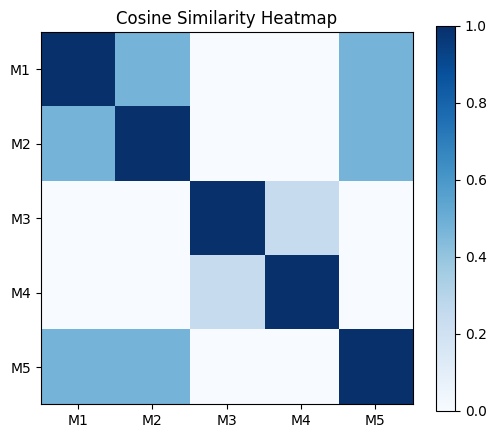

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(similarity_df, cmap='Blues')

plt.colorbar()

plt.xticks(range(len(df)), df["Movie_ID"])
plt.yticks(range(len(df)), df["Movie_ID"])

plt.title("Cosine Similarity Heatmap")

plt.show()

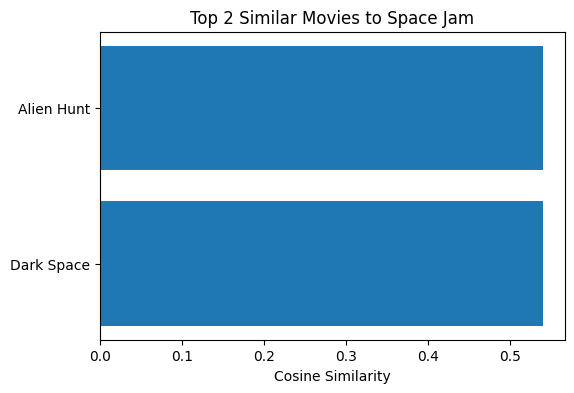

In [5]:
top_movies = ["Dark Space","Alien Hunt"]
scores = [0.54,0.54]

plt.figure(figsize=(6,4))

plt.barh(top_movies, scores)

plt.xlabel("Cosine Similarity")
plt.title("Top 2 Similar Movies to Space Jam")

plt.show()